In [1]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



In [2]:
#import data


In [7]:
data= pd.read_csv("../Data/useCarData.csv", sep=";")
data.head()


,Brand and model,Year of manufacture,Mileage,Engine power (hp),Fuel type,Transmission type,Trim level / Equipment line,Vehicle condition,Origin,Energy consumption,...,Panel gaps & fit,Windows & lights,Tires & wheels,Undercarriage & edges,Seats & upholstery,Dashboard & controls,Headliner & carpets,Trunk,Odor,Extras
0,BMW 3 Series,2013,114835,141,petrol,manual,Limited,acceptable,dealer,7.5,...,Uneven,Clear,Damaged,Clean,Torn,Worn,Sagging,Rust,Smoke,"Alloy wheels, Panoramic roof, Lane-keeping ass..."
1,Skoda Fabia,2012,166151,135,diesel,manual,Base,acceptable,private,8.0,...,Slightly uneven,Cracked or yellowed,Uneven wear,Oil stains,Torn,Good,Sagging,Clean,Moisture,Panoramic roof
2,BMW X3,2016,168960,196,petrol,automatic,Sport,good,trade-in,4.9,...,Uneven,Minor scratches,Even wear,Minor rust,Worn,Worn,Minor stains,Minor stains,Pet odor,"Panoramic roof, Alloy wheels, Lane-keeping ass..."
3,BMW 5 Series,2008,117128,122,petrol,manual,Comfort,very good,import,5.5,...,Even,Minor scratches,Damaged,Water damage,Worn,Excellent,Clean,Rust,Smoke,"Alloy wheels, Lane-keeping assist"
4,Skoda Octavia,2015,102098,60,petrol,automatic,Comfort,good,dealer,5.6,...,Even,Minor scratches,Damaged,Oil stains,Excellent,Good,Clean,Rust,Moisture,"Lane-keeping assist, Trailer hitch, Alloy whee..."


In [8]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 41 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Brand and model                       100 non-null    object 
 1   Year of manufacture                   100 non-null    int64  
 2   Mileage                               100 non-null    int64  
 3   Engine power (hp)                     100 non-null    int64  
 4   Fuel type                             100 non-null    object 
 5   Transmission type                     100 non-null    object 
 6   Trim level / Equipment line           100 non-null    object 
 7   Vehicle condition                     100 non-null    object 
 8   Origin                                100 non-null    object 
 9   Energy consumption                    100 non-null    float64
 10  Power output (kW)                     100 non-null    float64
 11  Category / Vehicle t

,Year of manufacture,Mileage,Engine power (hp),Energy consumption,Power output (kW),Engine displacement (cc),Price (EUR),Number of doors,Number of seats,Number of previous owners,Sale price,Dealer rating
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.00,100.000000,100.000000,49.000000
mean,2014.860000,94739.830000,140.710000,6.815000,104.92500,1867.840000,23453.610000,4.170000,4.94,2.860000,23453.610000,3.759184
std,5.720811,40885.783672,54.353184,2.237078,40.53542,529.278196,14857.978389,0.620443,0.60,1.356019,14857.978389,0.755237
min,2005.000000,7604.000000,60.000000,3.100000,44.70000,1000.000000,1500.000000,2.000000,2.00,1.000000,1500.000000,2.600000
25%,2010.000000,65977.750000,99.500000,5.300000,74.22500,1400.000000,12068.750000,4.000000,5.00,2.000000,12068.750000,3.000000
50%,2015.000000,100197.500000,135.500000,6.400000,101.05000,1998.000000,23612.500000,4.000000,5.00,3.000000,23612.500000,3.900000
75%,2020.000000,115048.500000,182.000000,8.100000,135.75000,2200.000000,32723.500000,5.000000,5.00,4.000000,32723.500000,4.400000
max,2024.000000,197197.000000,288.000000,15.700000,214.80000,3500.000000,75938.000000,5.000000,7.00,5.000000,75938.000000,5.000000


0     31067
1     18722
2     15427
3     15479
4      1500
      ...  
95    30236
96    19086
97    33894
98    34594
99    30814
Name: Price (EUR), Length: 100, dtype: int64


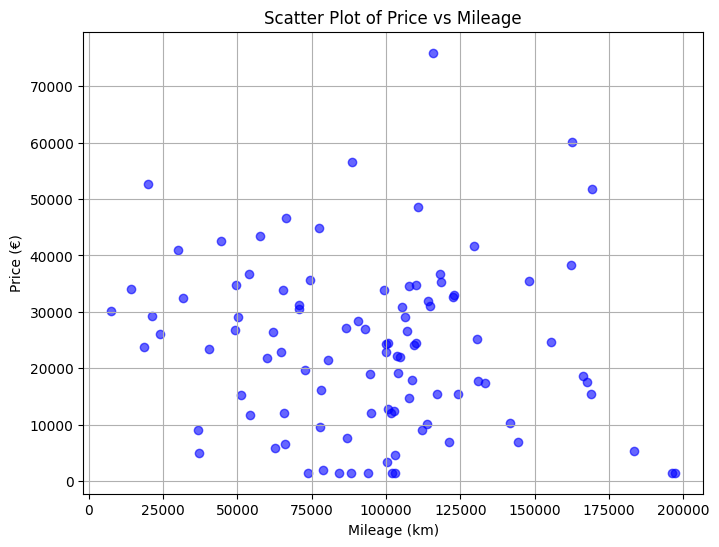

In [42]:
y=data["Price (EUR)"]
x=data["Mileage"]

# plt.bar(x,y)
# # Add labels and title
# plt.xlabel('Price in EUR')
# plt.ylabel('Mileage')
print(y)
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='blue', alpha=0.6)
plt.ylabel('Price (€)')
plt.xlabel('Mileage (km)')
plt.title('Scatter Plot of Price vs Mileage')
plt.grid(True)
plt.show()



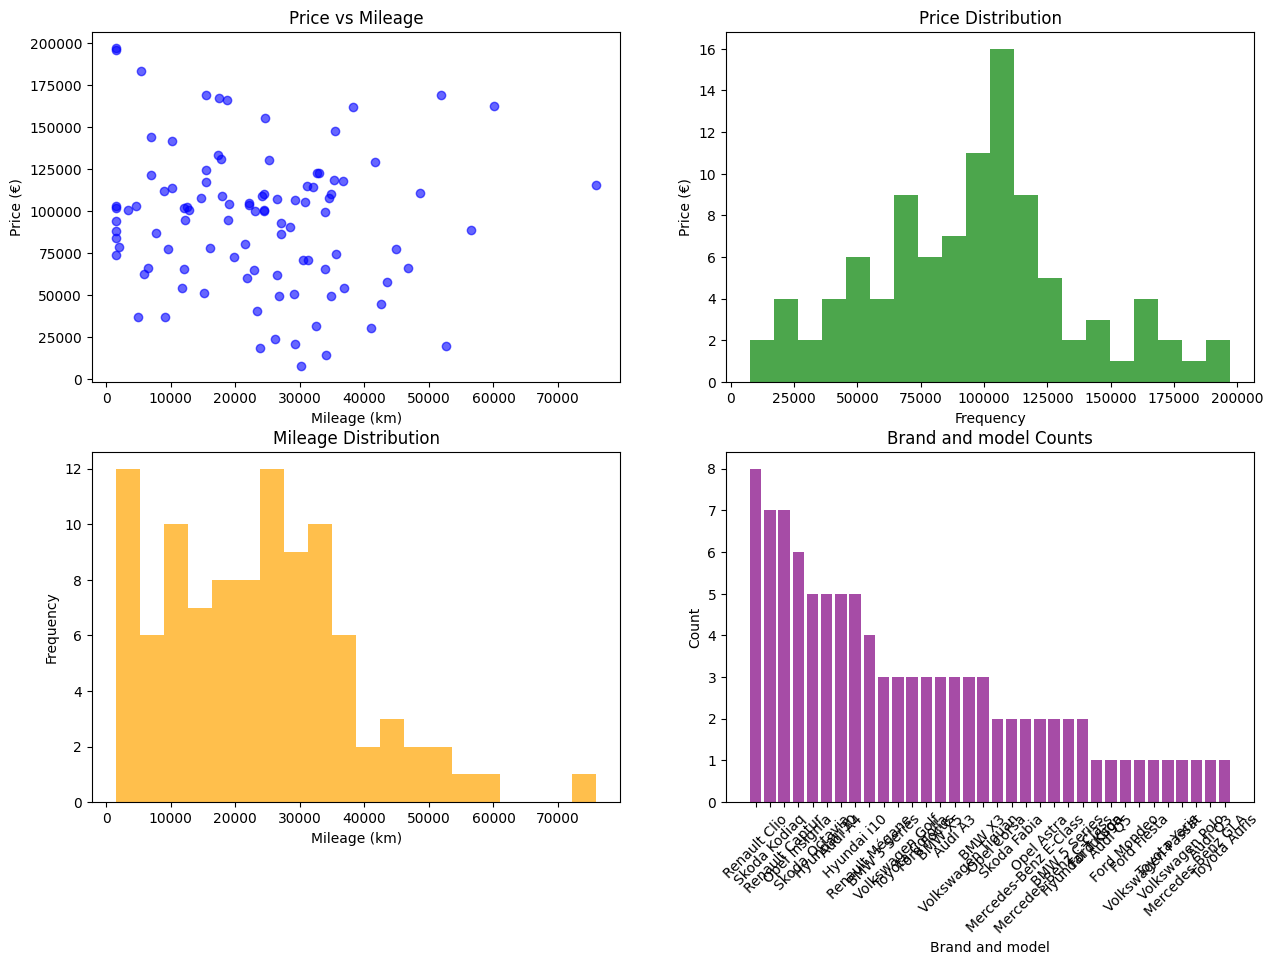

In [35]:
#print(data.columns)

# Prepare figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1️⃣ Scatter plot: price vs mileage
axes[0, 0].scatter(x, y, color='blue', alpha=0.6)
axes[0, 0].set_ylabel('Price (€)')
axes[0, 0].set_xlabel('Mileage (km)')
axes[0, 0].set_title('Price vs Mileage')

# 2️⃣ Histogram of price
axes[0, 1].hist(y, bins=20, color='green', alpha=0.7)
axes[0, 1].set_ylabel('Price (€)')
axes[0, 1].set_xlabel('Frequency')
axes[0, 1].set_title('Price Distribution')

# 3️⃣ Histogram of mileage
axes[1, 0].hist(x, bins=20, color='orange', alpha=0.7)
axes[1, 0].set_xlabel('Mileage (km)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Mileage Distribution')

# 4️⃣ Bar chart of categorical column
categorical_column = 'dealer' if 'dealer' in data.columns else data.columns[0]

category_counts = data[categorical_column].value_counts()
axes[1, 1].bar(category_counts.index, category_counts.values, color='purple', alpha=0.7)
axes[1, 1].set_xlabel(categorical_column)
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title(f'{categorical_column} Counts')
axes[1, 1].tick_params(axis='x', rotation=45) 
